# Analysis to determine rig dependence

In [98]:
"""
Rectified stereo anisotropy-invariance test.

Claim: image-plane anisotropy of Σ_r (direction + eigenvalue ratio of the
2×2 restriction perpendicular to the viewing ray) is approximately rig-
invariant across rectified rigs differing in baseline and orientation.
Depth-axis variance can vary with rig (via depth-gradient term).

Test setup:
  - Rectified rigs: {narrow, wide} × {horizontal, vertical} baselines
  - Anisotropic pixel noise (spatially constant, elongated 30°)
  - Surfaces: fronto-parallel plane, slanted plane, curved surface
  - Matched keypoints visible in all 4 rigs
"""

import numpy as np
from dataclasses import dataclass


# Rig
def get_rectified_transform(baseline, direction='horizontal'):
    R = np.eye(3)
    if direction == 'horizontal':
        t = np.array([baseline, 0.0, 0.0])
    elif direction == 'vertical':
        t = np.array([0.0, baseline, 0.0])
    else:
        raise ValueError(direction)
    return R, t


RIGS = {
    'rect_narrow_horiz': dict(baseline=0.25, direction='horizontal'),
    'rect_wide_horiz':   dict(baseline=2.00, direction='horizontal'),
    'rect_narrow_vert':  dict(baseline=0.25, direction='vertical'),
    'rect_wide_vert':    dict(baseline=2.00, direction='vertical'),
}


K_DEFAULT = np.array([
    [320.0,   0.0, 320.0],
    [  0.0, 320.0, 240.0],
    [  0.0,   0.0,   1.0]
])
IMAGE_SIZE = (640, 480)


def project(X_cam, K):
    valid = X_cam[:, 2] > 1e-6
    x = (K @ X_cam.T).T
    pixels = np.zeros_like(x[:, :2])
    pixels[valid] = x[valid, :2] / x[valid, 2:3]
    return pixels, valid


def lift(pixels, depths, K):
    pixels_hom = np.concatenate([pixels, np.ones((len(pixels), 1))], axis=1)
    rays = pixels_hom @ np.linalg.inv(K).T
    return rays * depths[:, None]


def in_bounds(pixels, image_size=IMAGE_SIZE):
    w, h = image_size
    return ((pixels[:, 0] >= 0) & (pixels[:, 0] < w) &
            (pixels[:, 1] >= 0) & (pixels[:, 1] < h))


# ---------------------------------------------------------------------------
# Surfaces
# ---------------------------------------------------------------------------

class Plane:
    """n · X = d_plane in LEFT frame."""
    def __init__(self, z0=8.0, slant_x=0.0, slant_y=0.0):
        nx = -np.sin(slant_x); ny = -np.sin(slant_y)
        nz = -np.sqrt(max(1.0 - nx**2 - ny**2, 1e-12))
        self.n_L = np.array([nx, ny, nz])
        self.d_plane_L = self.n_L[2] * z0
        self.z0 = z0

    def _depth_grad(self, pixels, K, n, d_plane):
        K_inv = np.linalg.inv(K)
        N = len(pixels)
        pix_hom = np.concatenate([pixels, np.ones((N, 1))], axis=1)
        r = pix_hom @ K_inv.T
        nr = r @ n
        s = d_plane / nr
        z = s * r[:, 2]
        dr_duv = K_inv[:, :2]
        dr_z_duv = dr_duv[2, :]
        n_dot_dr_duv = n @ dr_duv
        num = (dr_z_duv[None, :] * nr[:, None]
               - r[:, 2:3] * n_dot_dr_duv[None, :])
        denom = nr[:, None] ** 2
        dz_duv = d_plane * num / denom
        return z, dz_duv

    def sample_keypoints(self, num_samples, K, image_size, rng):
        w, h = image_size
        margin = 20
        u = rng.uniform(margin, w - margin, num_samples)
        v = rng.uniform(margin, h - margin, num_samples)
        pixels = np.stack([u, v], axis=1)
        z, _ = self._depth_grad(pixels, K, self.n_L, self.d_plane_L)
        pts_L = lift(pixels, z, K)
        good = (z > 1.0) & (z < 50.0)
        return pts_L[good]

    def depth_and_grad_in_frame(self, pixels, K, R=None, t=None):
        if R is None:
            return self._depth_grad(pixels, K, self.n_L, self.d_plane_L)
        n_f = R.T @ self.n_L
        d_f = self.d_plane_L - self.n_L @ t
        return self._depth_grad(pixels, K, n_f, d_f)


class CurvedSurface:
    """Z_L = z0 + a*X_L + b*X_L^2 + c*Y_L^2 in LEFT frame."""
    def __init__(self, z0=8.0, a=0.4, b=0.03, c=0.02):
        self.z0, self.a, self.b, self.c = z0, a, b, c

    def _depth_grad_left(self, pixels, K):
        K_inv = np.linalg.inv(K)
        N = len(pixels)
        pix_hom = np.concatenate([pixels, np.ones((N, 1))], axis=1)
        r = pix_hom @ K_inv.T
        rx, ry, rz = r[:, 0], r[:, 1], r[:, 2]
        assert np.allclose(rz, 1.0, atol=1e-10)

        # Solve z = f(z*rx, z*ry) by Newton (rz = 1)
        z = np.full(N, self.z0)
        for _ in range(30):
            X = z * rx; Y = z * ry
            f = self.z0 + self.a*X + self.b*X**2 + self.c*Y**2
            dfdX = self.a + 2*self.b*X
            dfdY = 2*self.c*Y
            F = z - f
            dFdz = 1 - dfdX*rx - dfdY*ry
            z = z - F / dFdz

        drx_duv = K_inv[0, :2]; dry_duv = K_inv[1, :2]
        dfdX = self.a + 2*self.b*(z*rx)
        dfdY = 2*self.c*(z*ry)
        dFdz = 1 - dfdX*rx - dfdY*ry
        dFduv = -(dfdX[:, None]*z[:, None]*drx_duv[None, :]
                  + dfdY[:, None]*z[:, None]*dry_duv[None, :])
        dz_duv = -dFduv / dFdz[:, None]
        return z, dz_duv

    def _depth_grad_right(self, pixels, K, R, t):
        assert np.allclose(R, np.eye(3))
        tx, ty, tz = t
        assert abs(tz) < 1e-12
        K_inv = np.linalg.inv(K)
        N = len(pixels)
        pix_hom = np.concatenate([pixels, np.ones((N, 1))], axis=1)
        r = pix_hom @ K_inv.T
        rx, ry, rz = r[:, 0], r[:, 1], r[:, 2]

        # X_L = z*rx + tx; Y_L = z*ry + ty; Z_L = z*rz; solve Z_L = f(X_L, Y_L)
        z = np.full(N, self.z0)
        for _ in range(50):
            X_L = z*rx + tx; Y_L = z*ry + ty; Z_L = z*rz
            f = self.z0 + self.a*X_L + self.b*X_L**2 + self.c*Y_L**2
            F = Z_L - f
            dfdX = self.a + 2*self.b*X_L
            dfdY = 2*self.c*Y_L
            dFdz = rz - dfdX*rx - dfdY*ry
            z = z - F / dFdz

        drx_duv = K_inv[0, :2]; dry_duv = K_inv[1, :2]; drz_duv = K_inv[2, :2]
        X_L = z*rx + tx; Y_L = z*ry + ty
        dfdX = self.a + 2*self.b*X_L
        dfdY = 2*self.c*Y_L
        dFdz = rz - dfdX*rx - dfdY*ry
        dFduv = (z[:, None]*drz_duv[None, :]
                 - dfdX[:, None]*z[:, None]*drx_duv[None, :]
                 - dfdY[:, None]*z[:, None]*dry_duv[None, :])
        dz_duv = -dFduv / dFdz[:, None]
        return z, dz_duv

    def sample_keypoints(self, num_samples, K, image_size, rng):
        w, h = image_size
        margin = 20
        u = rng.uniform(margin, w - margin, num_samples)
        v = rng.uniform(margin, h - margin, num_samples)
        pixels = np.stack([u, v], axis=1)
        z, _ = self._depth_grad_left(pixels, K)
        pts_L = lift(pixels, z, K)
        good = (z > 1.0) & (z < 50.0)
        return pts_L[good]

    def depth_and_grad_in_frame(self, pixels, K, R=None, t=None):
        if R is None:
            return self._depth_grad_left(pixels, K)
        return self._depth_grad_right(pixels, K, R, t)


# ---------------------------------------------------------------------------
# J_eff
# ---------------------------------------------------------------------------

def theoretical_sigma_r(X_L, X_R, R, Sigma_2d_L, Sigma_2d_R, K,
                        grad_d_L=None, grad_d_R=None):
    K_inv = np.linalg.inv(K)
    def j_eff(X, grad_d):
        z = X[2]; J_direct = z * K_inv[:, :2]
        if grad_d is None: return J_direct
        return J_direct + np.outer(X / z, grad_d)
    J_L = j_eff(X_L, grad_d_L)
    J_R = j_eff(X_R, grad_d_R)
    Sigma_L_3D = J_L @ Sigma_2d_L @ J_L.T
    Sigma_R_3D = J_R @ Sigma_2d_R @ J_R.T
    return Sigma_L_3D + R @ Sigma_R_3D @ R.T


# ---------------------------------------------------------------------------
# Decomposition: in-plane (⊥ viewing ray) + depth-axis
# ---------------------------------------------------------------------------

def decompose(Sigma, X_L):
    """Rotate Σ into (e1, e2, r̂) basis; return in-plane 2×2, depth-var,
    anisotropy ratio, principal in-plane direction in 3D."""
    ray = X_L / np.linalg.norm(X_L)
    tmp = np.array([1.0, 0.0, 0.0]) if abs(ray[0]) < 0.9 else np.array([0.0, 1.0, 0.0])
    e1 = tmp - (tmp @ ray) * ray
    e1 = e1 / np.linalg.norm(e1)
    e2 = np.cross(ray, e1)
    B = np.stack([e1, e2, ray], axis=1)
    Sigma_B = B.T @ Sigma @ B
    ip = Sigma_B[:2, :2]
    dv = Sigma_B[2, 2]
    eigs, V = np.linalg.eigh(ip)
    lam_max, lam_min = eigs[1], max(eigs[0], 1e-20)
    princ = V[0, -1]*e1 + V[1, -1]*e2
    return {
        'in_plane': ip,
        'depth_var': dv,
        'aniso_ratio': lam_max / lam_min,
        'in_plane_trace': np.trace(ip),
        'princ_3d': princ,
    }


# ---------------------------------------------------------------------------
# Anisotropic pixel noise
# ---------------------------------------------------------------------------

def make_anisotropic_pixel_noise(pixels, sigma_max, sigma_min, angle_deg):
    """Spatially-constant anisotropic 2×2 per-pixel covariance."""
    N = len(pixels)
    t = np.deg2rad(angle_deg)
    c, s = np.cos(t), np.sin(t)
    U = np.array([[c, -s], [s, c]])
    D = np.diag([sigma_max**2, sigma_min**2])
    Sigma = U @ D @ U.T
    return np.tile(Sigma[None, :, :], (N, 1, 1))


# ---------------------------------------------------------------------------
# Core experiment
# ---------------------------------------------------------------------------

def run_anisotropy_test(surface, rigs, pixel_noise_fn,
                        num_samples=3000, num_trials=500, seed=42,
                        K=None, image_size=IMAGE_SIZE):
    K = K if K is not None else K_DEFAULT
    rng = np.random.default_rng(seed)

    pts_L_all = surface.sample_keypoints(num_samples, K, image_size, rng)
    x_L_all, vL = project(pts_L_all, K)

    mask = vL & in_bounds(x_L_all, image_size)
    for rig_name in rigs:
        R, t = get_rectified_transform(**RIGS[rig_name])
        pts_R_rig = (pts_L_all - t) @ R
        x_R_rig, vR = project(pts_R_rig, K)
        mask &= vR & in_bounds(x_R_rig, image_size)

    # Filter pathological gradients (near-tangent rays). These make the
    # first-order J_eff break down and produce huge residuals that don't
    # match theory. Real-data filtering handles this via essential-matrix /
    # disparity checks; here we filter analytically on the gradient norm.
    _, grad_L_check = surface.depth_and_grad_in_frame(x_L_all, K)
    grad_L_mag = np.linalg.norm(grad_L_check, axis=1)
    mask &= grad_L_mag < 0.5  # gradient magnitude sanity bound

    pts_L = pts_L_all[mask]
    x_L = x_L_all[mask]
    N = len(pts_L)
    print(f"  Matched keypoints across all rigs: {N}")

    Sigma_2d_L = pixel_noise_fn(x_L)
    z_L, grad_d_L = surface.depth_and_grad_in_frame(x_L, K)

    results = {}
    results['_meta'] = {'pts_L': pts_L, 'x_L': x_L}
    for rig_name in rigs:
        R, t = get_rectified_transform(**RIGS[rig_name])
        pts_R = (pts_L - t) @ R
        x_R, _ = project(pts_R, K)
        z_R, grad_d_R = surface.depth_and_grad_in_frame(x_R, K, R, t)
        Sigma_2d_R = pixel_noise_fn(x_R)

        # Theoretical
        theo = np.zeros((N, 3, 3))
        for i in range(N):
            theo[i] = theoretical_sigma_r(
                pts_L[i], pts_R[i], R, Sigma_2d_L[i], Sigma_2d_R[i], K,
                grad_d_L=grad_d_L[i], grad_d_R=grad_d_R[i])

        # Empirical via noise loop
        all_res = np.zeros((N, num_trials, 3))
        L_chol = np.linalg.cholesky(Sigma_2d_L + 1e-12 * np.eye(2))
        R_chol = np.linalg.cholesky(Sigma_2d_R + 1e-12 * np.eye(2))
        for trial in range(num_trials):
            eps_L = np.einsum('nij,nj->ni', L_chol,
                              rng.standard_normal((N, 2)))
            eps_R = np.einsum('nij,nj->ni', R_chol,
                              rng.standard_normal((N, 2)))
            x_L_n = x_L + eps_L
            x_R_n = x_R + eps_R
            z_L_n, _ = surface.depth_and_grad_in_frame(x_L_n, K)
            z_R_n, _ = surface.depth_and_grad_in_frame(x_R_n, K, R, t)
            X_L_n = lift(x_L_n, z_L_n, K)
            X_R_n = lift(x_R_n, z_R_n, K)
            X_R_in_L = X_R_n @ R.T + t
            all_res[:, trial, :] = X_L_n - X_R_in_L

        emp = np.zeros((N, 3, 3))
        for i in range(N):
            emp[i] = np.cov(all_res[i].T)

        # Decompose each into (in-plane, depth-axis)
        ipt = np.zeros(N); dv = np.zeros(N)
        ar = np.zeros(N); princ = np.zeros((N, 3))
        ip_full = np.zeros((N, 2, 2))
        for i in range(N):
            d = decompose(emp[i], pts_L[i])
            ipt[i] = d['in_plane_trace']; dv[i] = d['depth_var']
            ar[i] = d['aniso_ratio']; princ[i] = d['princ_3d']
            ip_full[i] = d['in_plane']

        # Frob err between emp and theo
        frob = np.array([np.linalg.norm(emp[i] - theo[i], 'fro')
                         / (np.linalg.norm(theo[i], 'fro') + 1e-20)
                         for i in range(N)])

        results[rig_name] = {
            'in_plane_trace': ipt, 'depth_var': dv,
            'aniso_ratio': ar, 'princ_3d': princ, 'frob_err': frob,
            'in_plane_2x2': ip_full,
        }

    return results


def print_comparison(results):
    rigs_only = {k: v for k, v in results.items() if not k.startswith('_')}
    print(f"\n  {'Rig':<22} {'in-plane tr':>14} {'depth var':>14} "
          f"{'aniso ratio':>14} {'Frob err':>12}")
    for rig, r in rigs_only.items():
        print(f"  {rig:<22} {r['in_plane_trace'].mean():>14.4e} "
              f"{r['depth_var'].mean():>14.4e} "
              f"{np.median(r['aniso_ratio']):>14.3f} "
              f"{r['frob_err'].mean():>12.3%}")

    rigs = list(rigs_only.keys())
    print(f"\n  Pairwise (relative differences on matched keypoints):")
    print(f"  {'pair':<46} {'Δ in-plane':>12} {'Δ depth var':>14} "
          f"{'angle(princ)':>14}")
    for i, ri in enumerate(rigs):
        for rj in rigs[i+1:]:
            a, b = rigs_only[ri], rigs_only[rj]
            ipt_rel = (np.abs(a['in_plane_trace'] - b['in_plane_trace'])
                       / (np.abs(a['in_plane_trace']) + 1e-20)).mean()
            dv_rel = (np.abs(a['depth_var'] - b['depth_var'])
                      / (np.abs(a['depth_var']) + 1e-20)).mean()
            cos_ang = np.clip(
                np.abs(np.sum(a['princ_3d'] * b['princ_3d'], axis=1)), 0, 1)
            ang = np.rad2deg(np.arccos(cos_ang)).mean()
            print(f"  {ri:<22}↔ {rj:<22} {ipt_rel:>12.2%} "
                  f"{dv_rel:>14.2%} {ang:>12.2f}°")


def main():
    rigs = ['rect_narrow_horiz', 'rect_wide_horiz',
            'rect_narrow_vert',  'rect_wide_vert']
    pixel_noise = lambda pix: make_anisotropic_pixel_noise(
        pix, sigma_max=1.5, sigma_min=0.5, angle_deg=30.0)

    print("\n" + "=" * 78)
    print("Test 1: FRONTO-PARALLEL plane (no depth gradient anywhere)")
    print("Expected: in-plane Σ_r identical across all rigs; depth var ≈ 0")
    print("=" * 78)
    res_fp = run_anisotropy_test(Plane(z0=8.0, slant_x=0.0), rigs, pixel_noise)
    print_comparison(res_fp)

    print("\n" + "=" * 78)
    print("Test 2: SLANTED plane (30° about y-axis)")
    print("Expected: in-plane invariant (spatially-constant gradient);")
    print("          depth var INVARIANT across baselines (same ∇d everywhere);")
    print("          depth var differs between horiz/vert (gradient along x only)")
    print("=" * 78)
    res_sl = run_anisotropy_test(Plane(z0=8.0, slant_x=np.deg2rad(30)), rigs,
                                 pixel_noise)
    print_comparison(res_sl)

    print("\n" + "=" * 78)
    print("Test 3: CURVED surface (spatially-varying ∇d)")
    print("Expected: in-plane APPROXIMATELY invariant across rigs;")
    print("          depth var differs mildly because right pixel samples")
    print("          ∇d at different locations per rig.")
    print("=" * 78)
    # Gentler params — avoid near-tangent-ray regions at the image edges
    # where the implicit-function Jacobian blows up.
    res_cv = run_anisotropy_test(CurvedSurface(z0=8.0, a=0.15, b=0.005, c=0.005),
                                 rigs, pixel_noise)
    print_comparison(res_cv)

    return {'fronto': res_fp, 'slant': res_sl, 'curved': res_cv}



Test 1: FRONTO-PARALLEL plane (no depth gradient anywhere)
Expected: in-plane Σ_r identical across all rigs; depth var ≈ 0
  Matched keypoints across all rigs: 2338

  Rig                       in-plane tr      depth var    aniso ratio     Frob err
  rect_narrow_horiz          2.6711e-03     4.5012e-04          8.791       5.583%
  rect_wide_horiz            2.6774e-03     4.5044e-04          8.830       5.466%
  rect_narrow_vert           2.6750e-03     4.4880e-04          8.790       5.700%
  rect_wide_vert             2.6727e-03     4.5073e-04          8.743       5.542%

  Pairwise (relative differences on matched keypoints):
  pair                                             Δ in-plane    Δ depth var   angle(princ)
  rect_narrow_horiz     ↔ rect_wide_horiz               6.28%          7.04%         1.15°
  rect_narrow_horiz     ↔ rect_narrow_vert              6.49%          7.21%         1.16°
  rect_narrow_horiz     ↔ rect_wide_vert                6.44%          7.19%         1.

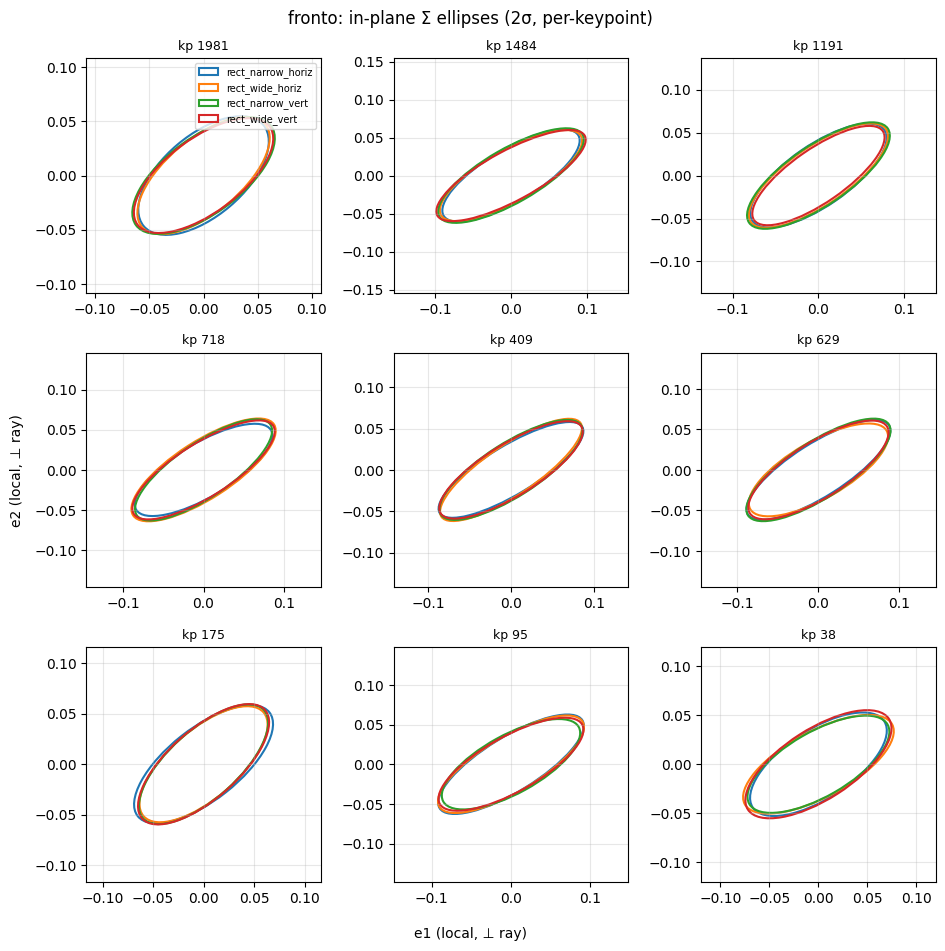

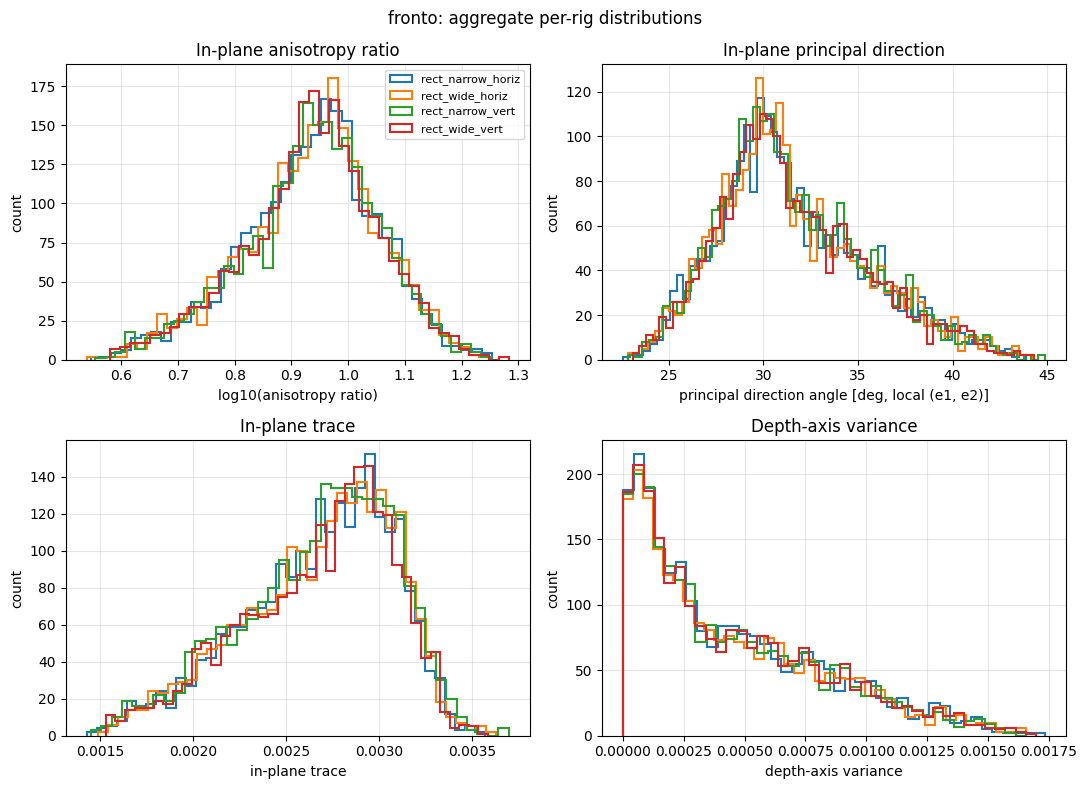

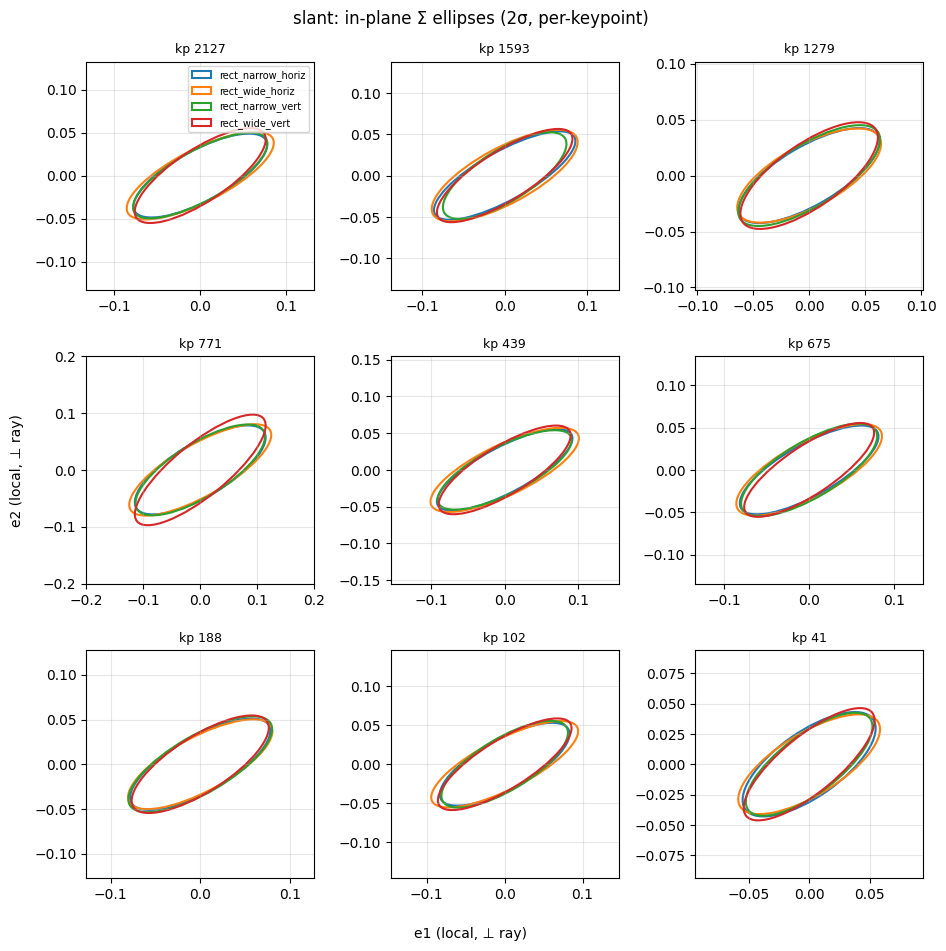

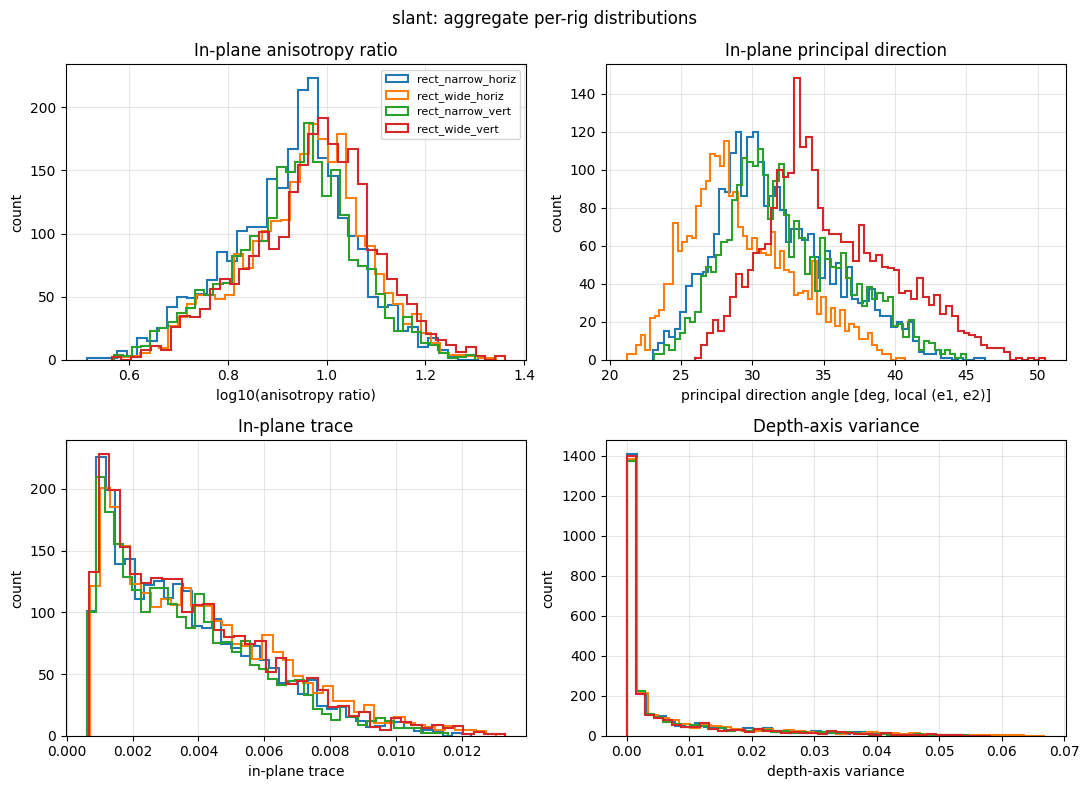

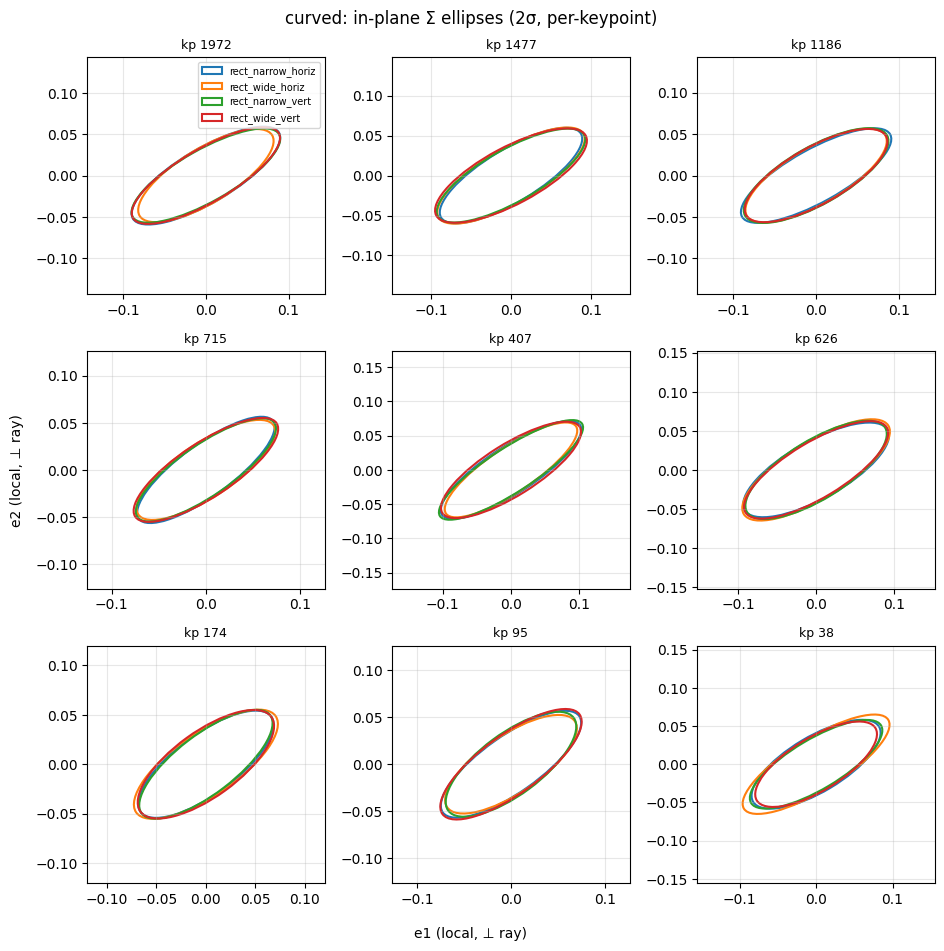

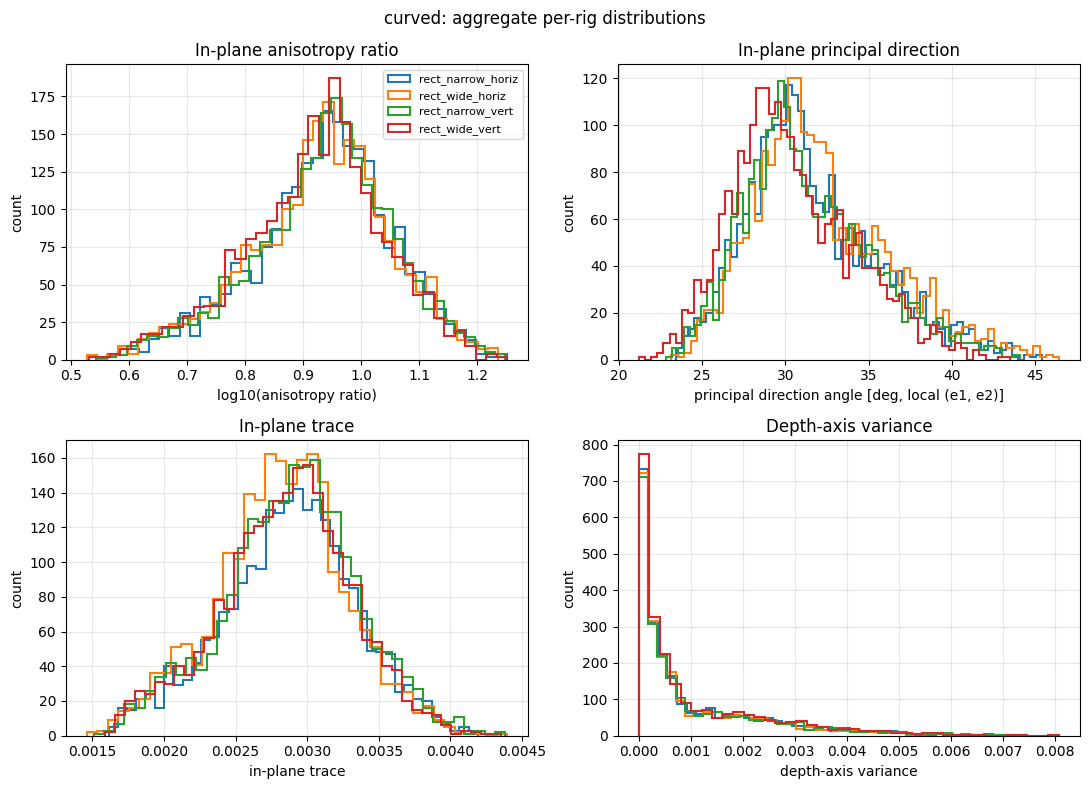

In [100]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

RIG_COLORS = {
    'rect_narrow_horiz': 'C0',
    'rect_wide_horiz':   'C1',
    'rect_narrow_vert':  'C2',
    'rect_wide_vert':    'C3',
}


def plot_ellipses_overlay(results, n_show=9, seed=0, sigma=2.0, title=None):
    """Overlay k-sigma in-plane ellipses per rig at n_show random keypoints,
    drawn in the local (e1, e2) basis ⊥ to the left viewing ray."""
    rng = np.random.default_rng(seed)
    rigs = [k for k in results if not k.startswith('_')]
    N = len(results[rigs[0]]['in_plane_2x2'])
    idx = rng.choice(N, size=min(n_show, N), replace=False)

    n_cols = int(np.ceil(np.sqrt(len(idx))))
    n_rows = int(np.ceil(len(idx) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2*n_cols, 3.2*n_rows),
                             squeeze=False)

    for k, ki in enumerate(idx):
        ax = axes[k // n_cols, k % n_cols]
        max_extent = 0.0
        for rig in rigs:
            C = results[rig]['in_plane_2x2'][ki]
            eigs, V = np.linalg.eigh(C)
            angle  = np.rad2deg(np.arctan2(V[1, -1], V[0, -1]))
            width  = 2 * sigma * np.sqrt(max(eigs[-1], 0))
            height = 2 * sigma * np.sqrt(max(eigs[0], 0))
            ax.add_patch(Ellipse((0, 0), width=width, height=height, angle=angle,
                                 edgecolor=RIG_COLORS[rig], facecolor='none',
                                 lw=1.5, label=rig))
            max_extent = max(max_extent, width, height)
        lim = max_extent * 0.7
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.set_aspect('equal'); ax.grid(alpha=0.3)
        ax.set_title(f'kp {ki}', fontsize=9)
        if k == 0:
            ax.legend(fontsize=7, loc='upper right')

    for k in range(len(idx), n_rows * n_cols):
        axes[k // n_cols, k % n_cols].axis('off')

    if title:
        fig.suptitle(title, fontsize=12)
    fig.supxlabel('e1 (local, ⊥ ray)', fontsize=10)
    fig.supylabel('e2 (local, ⊥ ray)', fontsize=10)
    fig.tight_layout()
    return fig


def plot_aggregate_hists(results, title=None):
    """Per-keypoint statistic histograms, overlaid per rig."""
    rigs = [k for k in results if not k.startswith('_')]
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))

    # anisotropy ratio (log scale — heavy tail)
    ax = axes[0, 0]
    for rig in rigs:
        ax.hist(np.log10(results[rig]['aniso_ratio']), bins=40,
                histtype='step', lw=1.5, color=RIG_COLORS[rig], label=rig)
    ax.set_xlabel('log10(anisotropy ratio)'); ax.set_ylabel('count')
    ax.set_title('In-plane anisotropy ratio')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # principal direction angle in local (e1, e2) frame, modulo 180°
    ax = axes[0, 1]
    for rig in rigs:
        ip = results[rig]['in_plane_2x2']
        _, V = np.linalg.eigh(ip)
        v_max = V[:, :, -1]
        ang = np.rad2deg(np.arctan2(v_max[:, 1], v_max[:, 0])) % 180
        ax.hist(ang, bins=60, histtype='step', lw=1.5,
                color=RIG_COLORS[rig], label=rig)
    ax.set_xlabel('principal direction angle [deg, local (e1, e2)]')
    ax.set_ylabel('count')
    ax.set_title('In-plane principal direction')
    ax.grid(alpha=0.3)

    # in-plane trace
    ax = axes[1, 0]
    for rig in rigs:
        ax.hist(results[rig]['in_plane_trace'], bins=40, histtype='step',
                lw=1.5, color=RIG_COLORS[rig], label=rig)
    ax.set_xlabel('in-plane trace'); ax.set_ylabel('count')
    ax.set_title('In-plane trace'); ax.grid(alpha=0.3)

    # depth variance
    ax = axes[1, 1]
    for rig in rigs:
        ax.hist(results[rig]['depth_var'], bins=40, histtype='step',
                lw=1.5, color=RIG_COLORS[rig], label=rig)
    ax.set_xlabel('depth-axis variance'); ax.set_ylabel('count')
    ax.set_title('Depth-axis variance'); ax.grid(alpha=0.3)

    if title:
        fig.suptitle(title, fontsize=12)
    fig.tight_layout()
    return fig


# Run once and plot all three tests
test_results = main()
for name, res in test_results.items():
    plot_ellipses_overlay(res, n_show=9,
                          title=f'{name}: in-plane Σ ellipses (2σ, per-keypoint)')
    plot_aggregate_hists(res,
                         title=f'{name}: aggregate per-rig distributions')
plt.show()
